---
tags: [algorithm, optimization, sample-based]
---

# Finite Imaginary-Time Evolution (FinITE) for PUBO

Imaginary-time evolution $e^{-\beta\hat H}$ exponentially suppresses excited states. 
Thus, for a cost Hamiltonian it concentrates a state on the optimum. Nonetheless, the process is not unitary, and
cannot be run directly on a quantum computer. 

The **FinITE** method realizes a *scaled* version of imaginary evolution
using a linear combination of unitaries (LCU) with post-selection.

> J. Kim, J. Kim, G. Lee, K. Baek, D. K. Park, J. Bang, J. Huh, "Finite Imaginary-Time Evolution for Polynomial Unconstrained Binary Optimization" [arXiv:2604.27482](https://arxiv.org/abs/2604.27482)) 


In this tutorial, we solve a **Max-3-XORSAT** instance with qamomile's `FinITEConverter`. Every term of that problem
is a three-body interaction, which makes it a natural fit: FinITE spends exactly one
ancilla per Pauli term, so here that is one ancilla per constraint, and higher-order
terms are block-encoded directly (rather than being reduced to a quadratic form first).

The tutorial is built as follows:

1. Introduction to the Max-3-XORSAT problem and modeling with `jijmodeling`.
2. Using the `FinITEConverter` and choosing the parameters.
3. Solving the instance : decoding and results.

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile
import os
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"

## 1. The Max-3-XORSAT Problem

### 1.1 Problem Settings

In **Max-3-XORSAT** we are given binary variables $x_0,\dots,x_{N-1}$ and a list of
*parity checks*. Each check names three variables and a target parity, and is satisfied
when

$$
x_i \oplus x_j \oplus x_k \;=\; t_c , \qquad t_c \in \{0, 1\},
$$

that is, when the number of ones among the three has the required parity. The task is to
satisfy as many checks as possible. 

XOR is awkward to write as a polynomial, but it becomes a plain product in **spin**
variables. Substituting

$$
s_i \;=\; 1 - 2 x_i \;\in\; \{+1, -1\},
$$

a bit that is 0 has spin $+1$ and a bit that is 1 has spin $-1$, so the product
$s_i s_j s_k$ is $+1$ exactly when an even number of the three bits are one. Writing the
target as a sign $\tau_c = (-1)^{t_c}$, the check is satisfied precisely when
$s_i s_j s_k = \tau_c$, and the number of violated checks is

$$
C(s) \;=\; \sum_c \frac{1 - \tau_c\, s_i s_j s_k}{2},
$$

which is $0$ per satisfied check and $1$ per violated one.

### 1.2 Define the Problem with JijModeling

In [2]:
import jijmodeling as jm

problem = jm.Problem("Max-3-XORSAT")


@problem.update
def _(problem: jm.DecoratedProblem):
    N = problem.Dim()
    C = problem.Natural(ndim=2)  # each row is one check: the three variables
    tau = problem.Float(ndim=1, latex=r"\tau")  # target sign: +1 even, -1 odd
    x = problem.BinaryVar(shape=(N,))

    # Work in spins rather than bits: s = 1 - 2x maps 0 -> +1 and 1 -> -1, so a
    # parity check is just a product of three spins.
    s = problem.NamedExpr("s", 1 - 2 * x, latex="s")

    # Number of violated checks: 0 when s_i s_j s_k matches the target sign, 1 otherwise.
    problem += (
        C.rows()
        .enumerate()
        .map(lambda c, v: (1 - tau[c] * s[v[0]] * s[v[1]] * s[v[2]]) / 2)
        .sum()
    )


problem

Problem(name="Max-3-XORSAT", sense=MINIMIZE, objective=sum(C.rows().enumerate().map(lambda ((c, v): Tuple[natural, Array[:; natural]]): (1 - tau[c] * s[v[0]] * s[v[1]] * s[v[2]]) / 2)), constraints=[])

### 1.3 The Instance

Six variables and eight checks, chosen so that exactly one assignment satisfies all of
them. 

In [3]:
NUM_VARS = 6
# Each check: the three variables it constrains, and the required parity of their sum.
CHECKS = [
    ([2, 3, 5], 0),
    ([0, 1, 3], 1),
    ([0, 3, 5], 1),
    ([1, 2, 5], 0),
    ([0, 2, 5], 0),
    ([0, 2, 3], 0),
    ([1, 4, 5], 1),
    ([3, 4, 5], 1),
]
CLAUSES = [variables for variables, _parity in CHECKS]
TARGETS = [1.0 if parity == 0 else -1.0 for _variables, parity in CHECKS]

instance = problem.eval({"N": NUM_VARS, "C": CLAUSES, "tau": TARGETS})

The bipartite graph below wires each check (square) to the three variables
(circles) it constrains.

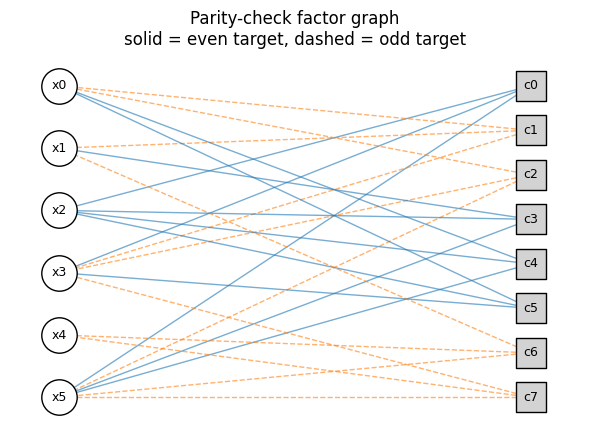

In [4]:
import math
import matplotlib.pyplot as plt
import networkx as nx

variable_nodes = [f"x{v}" for v in range(NUM_VARS)]
check_nodes = [f"c{c}" for c in range(len(CHECKS))]

graph = nx.Graph()
graph.add_nodes_from(variable_nodes)
graph.add_nodes_from(check_nodes)
for index, variables in enumerate(CLAUSES):
    graph.add_edges_from([(f"c{index}", f"x{v}") for v in variables])

# Explicit positions: variables on the left in index order, checks on the right.
layout = {name: (0.0, -pos) for pos, name in enumerate(variable_nodes)}
scale = (len(variable_nodes) - 1) / (len(check_nodes) - 1)
layout |= {name: (1.0, -pos * scale) for pos, name in enumerate(check_nodes)}

plt.figure(figsize=(6.0, 4.5))
# Solid edges for even-parity checks, dashed for odd, so the targets are visible.
for index, (variables, parity) in enumerate(CHECKS):
    nx.draw_networkx_edges(
        graph,
        layout,
        edgelist=[(f"c{index}", f"x{v}") for v in variables],
        edge_color="tab:blue" if parity == 0 else "tab:orange",
        style="solid" if parity == 0 else "dashed",
        alpha=0.6,
    )
nx.draw_networkx_nodes(
    graph, layout, nodelist=variable_nodes, node_color="white",
    edgecolors="black", node_size=650,
)
nx.draw_networkx_nodes(
    graph, layout, nodelist=check_nodes, node_color="lightgray",
    edgecolors="black", node_shape="s", node_size=450,
)
nx.draw_networkx_labels(graph, layout, font_size=9)
plt.title("Parity-check factor graph\nsolid = even target, dashed = odd target")
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. The FinITEConverter

### 2.1 Set Up the Converter

`FinITEConverter` takes the OMMX instance, converts it to a spin model, and holds the
identity-free Pauli terms that will be block-encoded.

In [5]:
from qamomile.optimization.finite_ite import FinITEConverter

converter = FinITEConverter(instance)


print(f"variables (system qubits) = {converter.spin_model.num_bits}")
print(f"Pauli terms  (ancillas)   = {converter.num_ancilla_bits}")
print(f"W = sum |x_mu|            = {converter.weight_norm} \n")

print("The problem results in a 3-body spin model :")
for term, coef in converter.spin_model.coefficients.items():
    print(f"{term} : {coef}")

variables (system qubits) = 6
Pauli terms  (ancillas)   = 8
W = sum |x_mu|            = 4.0 

The problem results in a 3-body spin model :
(0, 1, 3) : 0.5
(0, 2, 3) : -0.5
(0, 2, 5) : -0.5
(0, 3, 5) : 0.5
(1, 2, 5) : -0.5
(1, 4, 5) : 0.5
(2, 3, 5) : -0.5
(3, 4, 5) : 0.5


Two things to note:

1. The cost is one ancilla per constraint : FinITE uses one LCU block, and therefore one
ancilla, per Pauli term. Because each parity check *is* one Pauli term, the ancilla count
equals the number of checks: 8. A problem whose constraints expand into many Pauli terms
(a 3-SAT clause expands into seven) would cost proportionally more.

2. The three-body terms are used as they are : Methods restricted to quadratic models
must first *quadratize* each cubic term, introducing an auxiliary variable and a penalty
weight per term. FinITE block-encodes the cubic terms directly, so the search space stays
at $2^6$ and there are no penalty weights to tune.

### 2.2 Choosing $\beta$

The paper derives a *sufficient* $\beta$ for a target fidelity $\bar F$ (Corollary 2), by
inverting a gap-based lower bound on the ground-state fidelity $F_g$:

$$
\beta^\star(\bar F) \;=\; \max\left\{0,\ \frac{1}{2\Delta}\log\frac{\bar F(1-\gamma_0)}{\gamma_0(1-\bar F)}\right\}.
$$

Thus we need a bound on the spectral gap $\Delta$ and the initial ground-state overlap $\gamma_0$ (but no knowledge about the full spectrum). On a real instance, they would come from classical preprocessing or a warm start. 
The helper `finite_ite_beta_threshold` computes an appropriate for $\beta$ based on the paper computation.

In [6]:
from qamomile.optimization.finite_ite import finite_ite_beta_threshold

TARGET_FIDELITY = 0.95
GAP_BOUND = 2.0
INITIAL_OVERLAP_BOUND = 0.015625
W = converter.weight_norm

BETA = finite_ite_beta_threshold(
    TARGET_FIDELITY,
    spectral_gap=GAP_BOUND,
    ground_overlap=INITIAL_OVERLAP_BOUND,
)
print(f"beta* for F_g >= {TARGET_FIDELITY} : {BETA:.4f}")

beta* for F_g >= 0.95 : 1.7719


### 2.3 Transpiling into the quantum circuit

**Short summary of the method**  Because the Pauli-Z strings commute, the imaginary-time operator factorizes exactly and each factor collapses to two terms via $\sigma_\mu^2 = I$:

$$
e^{-\beta\hat H} \;=\; \prod_\mu \Big[\cosh(\beta|x_\mu|)\,I \;-\; \mathrm{sgn}(x_\mu)\sinh(\beta|x_\mu|)\,\sigma_\mu\Big].
$$

Each can be block encoded by LCU and the product is encoded by `stdlib/block_encoding/product.py`. The normalization of the total block encoding is $\alpha = e^{\beta W}$. 

The encoding can be accessed by `converter.block_encoding`

In [7]:
encoding = converter.block_encoding(BETA)
print(f"alpha   = {encoding.normalization:.6f}")
print(f"exp(bW) = {math.exp(BETA * W):.6f}")

alpha   = 1197.000000
exp(bW) = 1197.000000


For solving the problem, we just proceed by using the `transpile` method

In [8]:
from qamomile.qiskit import QiskitTranspiler
transpiler = QiskitTranspiler()

program = converter.transpile(transpiler, beta=BETA)
circuit = program.quantum_circuit
print(
    f"qubits = {circuit.num_qubits} "
    f"({NUM_VARS} system + {converter.num_ancilla_bits} ancillas)"
)
print(f"depth (fully decomposed) = {circuit.decompose(reps=6).depth()}")

qubits = 14 (6 system + 8 ancillas)
depth (fully decomposed) = 29


## 3. Solving the instance : Shot-based Results

### 3.1 Applying the Block-encoding

Now, we simply sample from the circuit and keep only the shots whose 8 ancillas all came out 0. That is when the block encoding succeeded. 

In [9]:
shots = 20_000 if docs_test_mode else 200_000
result = program.sample(transpiler.executor(), shots=shots).result()

acceptance = converter.success_probability(result)
sample_set = converter.decode(result)

print(f"shots = {shots}, acceptance rate = {acceptance:.4f}")

shots = 200000, acceptance rate = 0.0156


### 3.2 Decoding the results

Finally, we decode the survivors. `decode` applies the post-selection and, because the converter was built from an OMMX instance, returns an `ommx.v1.SampleSet` evaluated against the original objective, the number of unsatisfied checks.

In [10]:
best = sample_set.best_feasible
values = best.decision_variables_df["value"]
assignment = [int(values.loc[v]) for v in range(NUM_VARS)]
unsatisfied = sum(
    1
    for variables, parity in CHECKS
    if sum(assignment[v] for v in variables) % 2 != parity
)

print(f"\nbest assignment      = {assignment}")
print(f"unsatisfied checks   = {unsatisfied}  (objective = {best.objective:.0f})")


best assignment      = [1, 1, 0, 1, 1, 1]
unsatisfied checks   = 0  (objective = 0)


Every check is satisfied, so FinITE recovered the unique solution. 

## Summary

In this tutorial, we:

- Formulated Max-3-XORSAT with JijModeling, rewriting each parity check as a product
  of three spin variables $s_i = 1 - 2x_i$.
- Handed the OMMX instance to `FinITEConverter` and saw the cost operator come out as a
  purely 3-body spin model: 8 Pauli terms for 8 checks, so one ancilla per
  constraint, with no quadratization and no penalty weights.
- Chose $\beta$ with `finite_ite_beta_threshold`, the paper's gap-based threshold
  $\beta^\star(\bar F)$, which needs only estimates of the spectral gap $\Delta$ and the
  initial overlap $\gamma_0$. Targeting $F_g \ge 0.95$ gave
  $\beta^\star \approx 1.77$.
- Built the termwise-LCU block encoding of $m(\beta)e^{-\beta\hat H}$, confirmed its
  normalization is $\alpha = e^{\beta W} \approx 1197$, and transpiled it to a 14-qubit
  circuit (6 system + 8 ancillas).
- Sampled the circuit, post-selected the shots whose ancillas all read zero (about 1.6%
  of them), and decoded the survivors into an `ommx.v1.SampleSet`, recovering the unique
  assignment `[1, 1, 0, 1, 1, 1]` with every check satisfied.

**Not covered here.** Qamomile implements stage 1 of the paper, the block encoding. Stage
2, fixed-point amplitude amplification of the post-selection success probability, is not
included, so the run above pays the full $O(1/P_{\mathrm{LCU}})$ shot cost.